# DoriaNET Project - Group 9

**Members:** Alan Ray · Zach Shotwell · Miguel Moreno Coin  
**Course:** Artificial Intelligence, Appalachian State University  
**GitHub:** https://github.com/zachshotwell/AI-FinalProject-GroupSCR

**Dataset:**  
**Task:**  
**Approach:**

## Setup

In [1]:
!git clone https://github.com/zachshotwell/AI-FinalProject-GroupSCR
%cd AI-FinalProject-GroupSCR
%cd DoriaNETProject
!ls

Cloning into 'AI-FinalProject-GroupSCR'...
remote: Enumerating objects: 2140, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 2140 (delta 41), reused 4 (delta 2), pack-reused 2071 (from 2)
Receiving objects: 100% (2140/2140), 60.62 MiB | 27.71 MiB/s, done.
Resolving deltas: 100% (1700/1700), done.
/content/AI-FinalProject-GroupSCR
/content/AI-FinalProject-GroupSCR/DoriaNETProject
 data
 DoriaNET.ipynb
'DoriaNET report.pdf'
'main paper. Deep learning for post-hurricane aerial damage assessmentof buildings.pdf'
 README.md


In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

DATA_ROOT = Path('data')
FRAME_DIR = DATA_ROOT / 'FRAME'
MASK_DIR = DATA_ROOT / 'MASK'
JSON_DIR = DATA_ROOT / 'JSON'

DAMAGE_LABELS = {
    0: 'No damage',
    1: 'Minor',
    2: 'Moderate',
    3: 'Severe',
    4: 'Destruction',
    5: 'Under construction / destroyed'
}

TF: 2.20.0
GPU: []


In [4]:
frame_files = sorted(FRAME_DIR.glob("*.jpg"))
mask_files  = sorted(MASK_DIR.glob("*.jpg"))
json_files  = sorted(JSON_DIR.glob("*.json"))

print(f"FRAME : {len(frame_files):>5} files")
print(f"MASK  : {len(mask_files):>5} files")
print(f"JSON  : {len(json_files):>5} files")

print("\nSample names:")
for f in frame_files[:3]: print("  FRAME:", f.name)
for f in mask_files[:3]:  print("  MASK :", f.name)
for f in json_files[:3]:  print("  JSON :", f.name)

# Spot-check a single frame's resolution (paper says 1280×720)
img = plt.imread(frame_files[0])
print(f'Frame[0] shape: {img.shape}, dtype: {img.dtype}')
img = plt.imread(mask_files[0])
print(f'Mask[0] shape: {img.shape}, dtype: {img.dtype}')

FRAME :   271 files
MASK  :  1458 files
JSON  :   271 files

Sample names:
  FRAME: 1_0373.jpg
  FRAME: 1_0379.jpg
  FRAME: 1_0405.jpg
  MASK : 1_0373_B0XX_0_Level1.jpg
  MASK : 1_0379_B0XX_0_Level0.jpg
  MASK : 1_0379_B0XX_0_Level2.jpg
  JSON : 1_0373.json
  JSON : 1_0379.json
  JSON : 1_0405.json
Frame[0] shape: (720, 1280, 3), dtype: uint8
Mask[0] shape: (720, 1280, 3), dtype: uint8


In [6]:
sample_json = json_files[0]
with open(sample_json) as f:
  sample = json.load(f)

print(f'File: {sample_json.name}')
print(f'Top-level keys: {list(sample.keys())}\n')
print(json.dumps(sample, indent=2)[:2000])

File: 1_0373.json
Top-level keys: ['Frame_Name', 'Buildings', 'Capture date', 'Region', 'Original video link']

{
  "Frame_Name": "FRAME/1_0373.jpg",
  "Buildings": [
    [
      "B004",
      "26.55438, -77.0968",
      "1_0373_B0XX_0_Level1.jpg",
      1,
      1,
      1,
      NaN
    ]
  ],
  "Capture date": "09 September 2019",
  "Region": "Marsh Harbor, Abaco, the bahamas",
  "Original video link": "https://youtu.be/T0GojxvrFm8"
}


In [7]:
# Confirm every building is a 7-element list and inspect field-value distributions
all_buildings = []
for p in json_files:
    with open(p) as f:
        d = json.load(f)
    all_buildings.extend(d["Buildings"])

lengths = {len(b) for b in all_buildings}
print(f"Total buildings: {len(all_buildings)}")
print(f"Distinct row lengths: {lengths}")  # should be {7}

# Field-by-field value distribution for the unknown positions
for i in [3, 4, 5, 6]:
    vals = pd.Series([b[i] for b in all_buildings])
    print(f"\nField [{i}] — dtype: {vals.dtype}, n_unique: {vals.nunique(dropna=False)}, "
          f"NaN count: {vals.isna().sum()}")
    print(vals.value_counts(dropna=False).sort_index().head(10))

# Cross-check field [3] against the mask filename's _LevelN suffix
import re
level_re = re.compile(r"_Level(\d)\.jpg$")
mismatches = 0
for b in all_buildings:
    m = level_re.search(b[2])
    if m and int(m.group(1)) != b[3]:
        mismatches += 1
print(f"\nDamage-vs-filename mismatches: {mismatches} / {len(all_buildings)}")

Total buildings: 1458
Distinct row lengths: {7}

Field [3] — dtype: int64, n_unique: 6, NaN count: 0
0    168
1    264
2    196
3    464
4    258
5    108
Name: count, dtype: int64

Field [4] — dtype: int64, n_unique: 2, NaN count: 0
1    1257
2     201
Name: count, dtype: int64

Field [5] — dtype: int64, n_unique: 3, NaN count: 0
0     328
1    1029
2     101
Name: count, dtype: int64

Field [6] — dtype: float64, n_unique: 1, NaN count: 1458
NaN    1458
Name: count, dtype: int64

Damage-vs-filename mismatches: 0 / 1458


In [9]:
def parse_frame_json(path):
    with open(path) as f:
        d = json.load(f)
    rows = []
    for b in d["Buildings"]:                          # b is a 7-element list
        lat, lon = (float(x) for x in b[1].split(","))
        rows.append({
            "json_file":    path.name,
            "frame_name":   Path(d["Frame_Name"]).name,  # strip "FRAME/" prefix
            "building_id":  b[0],
            "lat":          lat,
            "lon":          lon,
            "mask_name":    b[2],
            "damage":       b[3],
            "stories":      b[4],
            "effort":       b[5],
            "region":       d.get("Region"),
            "capture_date": d.get("Capture date"),
            "video_url":    d.get("Original video link"),
        })
    return rows

records = [r for p in json_files for r in parse_frame_json(p)]
df = pd.DataFrame(records)

print(f"Total building instances: {len(df)}")
print(f"Distinct frames in JSON : {df['frame_name'].nunique()}")
print(f"Distinct mask filenames : {df['mask_name'].nunique()}")
print(f"Distinct building IDs   : {df['building_id'].nunique()}")
df.head()

Total building instances: 1458
Distinct frames in JSON : 271
Distinct mask filenames : 1458
Distinct building IDs   : 147


,json_file,frame_name,building_id,lat,lon,mask_name,damage,stories,effort,region,capture_date,video_url
0,1_0373.json,1_0373.jpg,B004,26.55438,-77.09680,1_0373_B0XX_0_Level1.jpg,1,1,1,"Marsh Harbor, Abaco, the bahamas",09 September 2019,https://youtu.be/T0GojxvrFm8
1,1_0379.json,1_0379.jpg,B001,26.55511,-77.10044,1_0379_B0XX_0_Level0.jpg,0,1,1,"Marsh Harbor, Abaco, the bahamas",09 September 2019,https://youtu.be/T0GojxvrFm8
2,1_0379.json,1_0379.jpg,B002,26.55516,-77.09986,1_0379_B0XX_0_Level2.jpg,2,1,1,"Marsh Harbor, Abaco, the bahamas",09 September 2019,https://youtu.be/T0GojxvrFm8
3,1_0379.json,1_0379.jpg,B003,26.55452,-77.09913,1_0379_B0XX_0_Level3.jpg,3,1,1,"Marsh Harbor, Abaco, the bahamas",09 September 2019,https://youtu.be/T0GojxvrFm8
4,1_0405.json,1_0405.jpg,B001,26.55511,-77.10044,1_0405_B0XX_0_Level0.jpg,0,1,1,"Marsh Harbor, Abaco, the bahamas",09 September 2019,https://youtu.be/T0GojxvrFm8


In [10]:
# How are the 1458 instances distributed across (frame prefix, building_id)?
prefix = df["frame_name"].str.extract(r"^(\d+)_")[0]
print("Frame name prefixes (likely video IDs):")
print(prefix.value_counts())

# Does (lat, lon) round-tripped to 5 decimals give us 147 unique values?
df["coord_key"] = df.apply(lambda r: (round(r["lat"], 5), round(r["lon"], 5)), axis=1)
print(f"\nDistinct (lat, lon) keys      : {df['coord_key'].nunique()}")
print(f"Distinct building_id alone    : {df['building_id'].nunique()}")
print(f"Distinct (prefix, building_id): {df.groupby([prefix, 'building_id']).ngroups}")

Frame name prefixes (likely video IDs):
0
2    755
3    535
1    168
Name: count, dtype: int64

Distinct (lat, lon) keys      : 147
Distinct building_id alone    : 147
Distinct (prefix, building_id): 163


In [11]:
print(df.groupby("building_id").size().describe())

count    147.000000
mean       9.918367
std        7.905703
min        1.000000
25%        4.000000
50%        8.000000
75%       13.000000
max       39.000000
dtype: float64


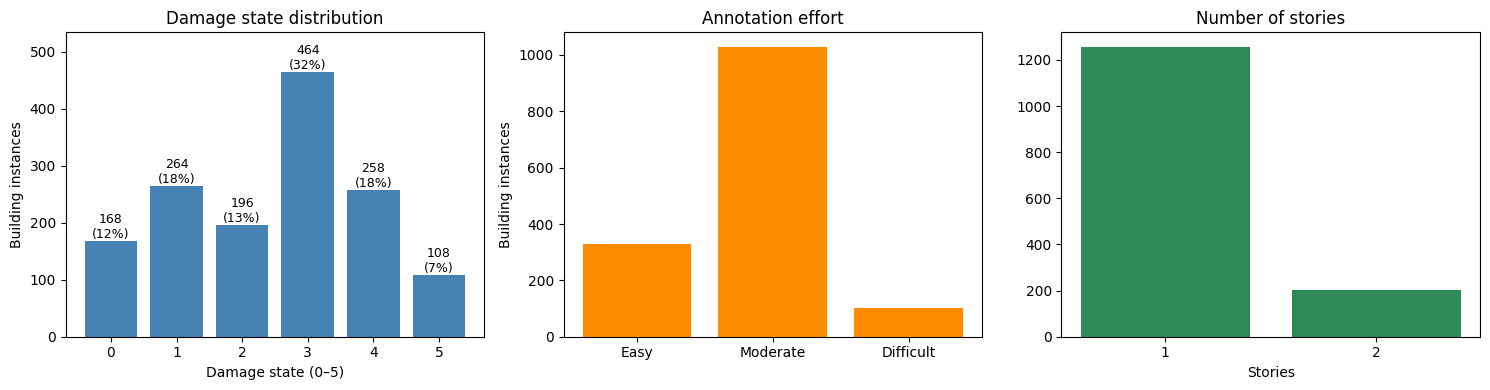


Damage × Effort cross-tab (counts):
effort    0     1    2   All
damage                      
0        26   126   16   168
1        65   193    6   264
2        42   134   20   196
3       133   300   31   464
4        50   195   13   258
5        12    81   15   108
All     328  1029  101  1458

Buildings per frame — mean: 5.4, median: 5, min: 1, max: 17


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Damage state
dmg_counts = df["damage"].value_counts().sort_index()
axes[0].bar(dmg_counts.index.astype(str), dmg_counts.values, color="steelblue")
axes[0].set_title("Damage state distribution")
axes[0].set_xlabel("Damage state (0–5)"); axes[0].set_ylabel("Building instances")
axes[0].set_ylim(0, dmg_counts.max() * 1.15)
for i, v in enumerate(dmg_counts.values):
    axes[0].text(i, v + 5, f"{v}\n({100*v/len(df):.0f}%)", ha="center", fontsize=9)

# Annotation effort
eff_counts = df["effort"].value_counts().sort_index()
eff_labels = {0: "Easy", 1: "Moderate", 2: "Difficult"}
axes[1].bar([eff_labels.get(i, str(i)) for i in eff_counts.index],
            eff_counts.values, color="darkorange")
axes[1].set_title("Annotation effort"); axes[1].set_ylabel("Building instances")

# Stories
st_counts = df["stories"].value_counts().sort_index()
axes[2].bar(st_counts.index.astype(str), st_counts.values, color="seagreen")
axes[2].set_title("Number of stories"); axes[2].set_xlabel("Stories")

plt.tight_layout(); plt.show()

# Cross-tab: damage × annotation effort (for reporting accuracy stratified by difficulty later)
print("\nDamage × Effort cross-tab (counts):")
print(pd.crosstab(df["damage"], df["effort"], margins=True))

# Buildings per frame
bpf = df.groupby("frame_name").size()
print(f"\nBuildings per frame — mean: {bpf.mean():.1f}, median: {bpf.median():.0f}, "
      f"min: {bpf.min()}, max: {bpf.max()}")

In [14]:
frame_set_disk = {p.name for p in frame_files}
mask_set_disk  = {p.name for p in mask_files}
frame_set_json = set(df["frame_name"].dropna())
mask_set_json  = set(df["mask_name"].dropna())

# (1) Every JSON-referenced frame exists on disk
missing_frames = frame_set_json - frame_set_disk
print(f"JSON frames missing from FRAME/ : {len(missing_frames)}")
if missing_frames: print("  examples:", list(missing_frames)[:5])

# (2) Every JSON-referenced mask exists on disk
missing_masks = mask_set_json - mask_set_disk
print(f"JSON masks  missing from MASK/  : {len(missing_masks)}")
if missing_masks: print("  examples:", list(missing_masks)[:5])

# (3) Orphans (files on disk that nothing references)
orphan_frames = frame_set_disk - frame_set_json
orphan_masks  = mask_set_disk  - mask_set_json
print(f"Orphan frames (on disk, no JSON ref): {len(orphan_frames)}")
print(f"Orphan masks  (on disk, no JSON ref): {len(orphan_masks)}")

# (4) Mask vs frame dimension agreement on a small sample
print("\nDimension check on 5 random masks vs their frames:")
for _, row in df.dropna(subset=["mask_name"]).sample(5, random_state=42).iterrows():
    fp = FRAME_DIR / row["frame_name"]
    mp = MASK_DIR  / row["mask_name"]
    fi = plt.imread(fp)
    mi = plt.imread(mp)
    print(f'  {row['frame_name']:<15} frame {fi.shape} vs mask {mi.shape} match={fi.shape == mi.shape}')

JSON frames missing from FRAME/ : 0
JSON masks  missing from MASK/  : 0
Orphan frames (on disk, no JSON ref): 0
Orphan masks  (on disk, no JSON ref): 0

Dimension check on 5 random masks vs their frames:
  3_0670.jpg      frame (720, 1280, 3) vs mask (720, 1280, 3) match=True
  2_0753.jpg      frame (720, 1280, 3) vs mask (720, 1280, 3) match=True
  2_0254.jpg      frame (720, 1280, 3) vs mask (720, 1280, 3) match=True
  2_0430.jpg      frame (720, 1280, 3) vs mask (720, 1280, 3) match=True
  3_0344.jpg      frame (720, 1280, 3) vs mask (720, 1280, 3) match=True


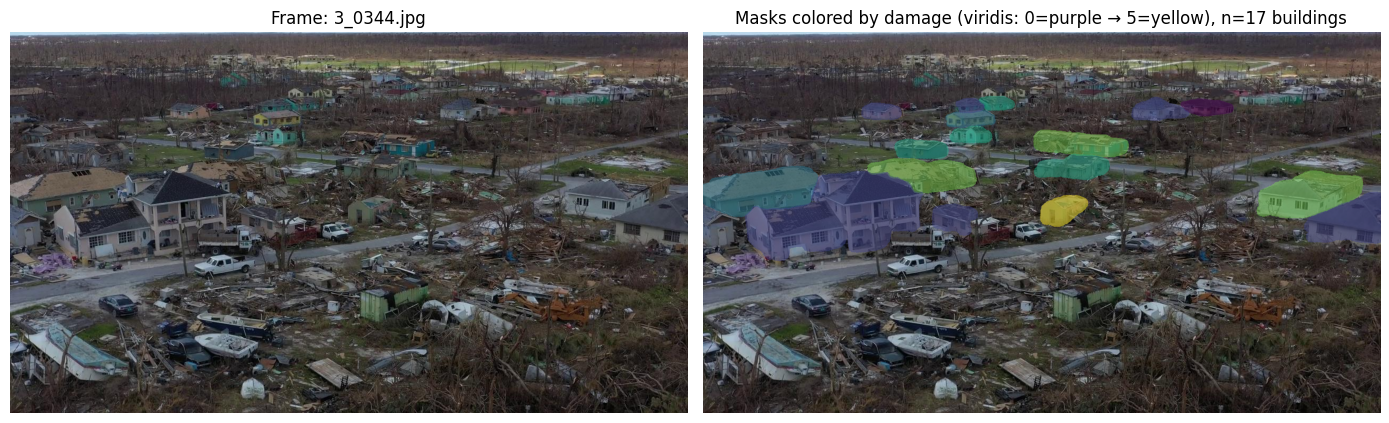

In [15]:
sample_frame = df["frame_name"].value_counts().idxmax()  # frame with most buildings
sample_rows  = df[df["frame_name"] == sample_frame]

base = plt.imread(FRAME_DIR / sample_frame).astype(float) / 255.0
overlay = base.copy()
cmap = plt.cm.viridis

for _, row in sample_rows.iterrows():
    m = plt.imread(MASK_DIR / row["mask_name"])
    if m.ndim == 3: m = m.mean(axis=-1)
    m = m > 127
    color = np.array(cmap(row["damage"] / 5)[:3])
    overlay[m] = 0.5 * overlay[m] + 0.5 * color

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(base);    axes[0].set_title(f"Frame: {sample_frame}"); axes[0].axis("off")
axes[1].imshow(overlay); axes[1].axis("off")
axes[1].set_title(f"Masks colored by damage (viridis: 0=purple → 5=yellow), n={len(sample_rows)} buildings")
plt.tight_layout(); plt.show()